In [2]:
import torch

if torch.cuda.is_available():
    device = "cuda" # la grafica NVIDIA
elif torch.backends.mps.is_available():
    device = "mps" # chip de apple (M1, M2, M3)
else:
    device = "cpu" # cpu
print(f"Using device: {device}")

Using device: cuda


In [3]:
# !pip install diffusers

In [4]:
# !pip install -U transformers diffusers huggingface_hub

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

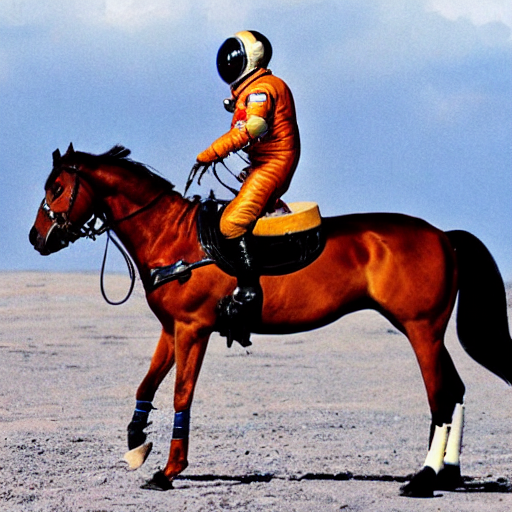

In [5]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
"stable-diffusion-v1-5/stable-diffusion-v1-5",
torch_dtype=torch.float16,variant="fp16",
).to(device)

prompt = "a photograph of an astronaut riding a horse"
pipe(prompt).images[0]

In [6]:
from transformers import pipeline

# Clasificación de sentimiento
classifier = pipeline("text-classification", device=device)
classifier("This movie is disgustingly good!")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998536109924316}]

In [9]:
generator = pipeline("text-generation", device=device)
generator("It was a dark and stormy")[0]["generated_text"]

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'It was a dark and stormy night, or so the saying goes. Now, a team of astronomers has found a pair of neutron stars colliding, which could help them learn more about the origins of cosmic events like the ones that created the Earth’s oceans and seeded it with heavy elements.\nThe neutron stars collided about 130 million years ago, according to the team from the University of Maryland and the National Optical Astronomy Observatory (NOAO), based in Tucson, Arizona. This is relatively recent in cosmic terms, and scientists are hoping to learn more about the event by studying the effects of the collision.\nThe collision, which occurred about 8,000 light-years from Earth, was detected on August 17, 2017, by the National Science Foundation’s Laser Interferometer Gravitational-Wave Observatory (LIGO). LIGO was designed to detect gravitational waves, ripples in spacetime produced by violent cosmic events.\nThe waves were picked up by LIGO’s two detectors, located in Hanford, Washington, and L